### Google Play Store Analysis
Name   : Muhamamd Ghazy Hikmatiar

Type   : Individual

Github : -

#### Description
--

#### Purposes
--

#### Dataset
--

#### Import Library

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Import Dataset

In [11]:
df = pd.read_csv('./googleplaystore.csv')
display(df.head())

df_review = pd.read_csv('./googleplaystore_user_reviews.csv')
display(df_review.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


#### Data Understanding (df)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [13]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [14]:
df.isna().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64

#### Data Cleaning (df)

In [15]:
# handling duplicate
print(f'Count Data App Duplicate : {df['App'].duplicated().sum()}')

df = df.sort_values(by="Reviews", ascending=False).drop_duplicates(subset=['App'], keep='first')
print(f'Count Data App Duplicate : {df['App'].duplicated().sum()}')

Count Data App Duplicate : 1181
Count Data App Duplicate : 0


In [16]:
# reset index
df.reset_index(drop=True, inplace=True)
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,GollerCepte Live Score,SPORTS,4.2,9992,31M,"1,000,000+",Free,0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,91k,"100,000+",Free,0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18M,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33M,"1,000,000+",Free,0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22M,"500,000+",Free,0,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,CE-STRONG,FAMILY,NaN,0,16M,100+,Free,0,Everyone,Education,"June 17, 2016",1.0.4,4.0 and up
9656,Anime Mod for BM,BOOKS_AND_REFERENCE,NaN,0,8.0M,100+,Free,0,Everyone,Books & Reference,"July 28, 2017",1.0,4.0 and up
9657,CE-SETRAM l’Appli,LIBRARIES_AND_DEMO,NaN,0,2.6M,100+,Free,0,Everyone,Libraries & Demo,"December 5, 2017",1.1.8,4.0.3 and up
9658,Glanceable Ap Watch Face,PERSONALIZATION,NaN,0,11M,5+,Paid,$0.99,Everyone,Personalization,"August 14, 2016",1.0.103,4.4 and up


In [17]:
# handling null values
df.isna().sum()
df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'], inplace=True)

In [18]:
# handling missing value in rating
df['Rating'].fillna("0")
df['Rating'] = df['Rating'].astype(float)
mean_rating = round(df['Rating'].mean(), 1)

df['Reviews'] = df['Reviews'].astype(int)

df.loc[(df['Rating'] == 0) & (df['Reviews'] != 0), "Rating"] = mean_rating
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,GollerCepte Live Score,SPORTS,4.2,9992,31M,"1,000,000+",Free,0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,91k,"100,000+",Free,0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18M,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33M,"1,000,000+",Free,0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22M,"500,000+",Free,0,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up


In [19]:
# cleaning size
def clean_size(value):
    if pd.isna(value) or value == 'Varies with device':
        return 'Varies with device'
    
    value = str(value).lower()
    if "m" in value:
        return float(value.replace('m', '')) 
    elif 'k' in value:
        return float(value.replace('k', '')) / 1000
    
    try:
        return float(value)
    except:
        return 'Varies with device'

df['Size'] = df['Size'].apply(clean_size)
df = df.rename(columns={"Size" : "Size (MB)"})
df.head()

,App,Category,Rating,Reviews,Size (MB),Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,GollerCepte Live Score,SPORTS,4.2,9992,31.0,"1,000,000+",Free,0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,0.091,"100,000+",Free,0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18.0,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33.0,"1,000,000+",Free,0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,"500,000+",Free,0,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up


In [20]:
# cleaning installs and price
df['Installs'] = df['Installs'].str.strip("+")
df['Installs'] = df['Installs'].str.replace(",", "").astype(int)

df['Price'] = df['Price'].str.strip("$")
df['Price'] = df['Price'].astype(float)
df.head()

,App,Category,Rating,Reviews,Size (MB),Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,GollerCepte Live Score,SPORTS,4.2,9992,31.0,1000000,Free,0.0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,0.091,100000,Free,0.0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18.0,1000000,Free,0.0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33.0,1000000,Free,0.0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up


In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
df['Content Rating'] = df['Content Rating'].replace("Unrated", np.nan)

le = LabelEncoder()
df['Category_Encoded'] = le.fit_transform(df['Category'])

train_df = df[df['Content Rating'].notna()]
predict_df = df[df['Content Rating'].isna()]
x_train = train_df[['Category_Encoded', 'Rating']]
y_train = train_df['Content Rating']
x_predict = predict_df[['Category_Encoded', 'Rating']]

model = RandomForestClassifier()
model.fit(x_train, y_train)

prediction = model.predict(x_predict)
print(prediction)

df.loc[df['Content Rating'].isna(), "Content Rating"] = prediction

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# cleanimg Current Ver and Android Ver
df[['Android Ver', 'Current Ver', 'Size (MB)']] = df[['Android Ver', 'Current Ver', 'Size (MB)']].replace("Varies with device", "0")

In [ ]:
df['Size (MB)'] = df['Size (MB)'].astype(float)

#### EDA (df)

In [ ]:
df.describe()

,Rating,Reviews,Size (MB),Installs,Price,Category_Encoded
count,9648.000000,9.648000e+03,9648.000000,9.648000e+03,9648.000000,9648.000000
mean,3.857038,2.168343e+05,17.817937,7.788915e+06,1.100193,16.770522
std,1.118972,1.832427e+06,21.500230,5.379005e+07,16.861727,8.393529
min,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,3.600000,2.500000e+01,2.900000,1.000000e+03,0.000000,11.000000
50%,4.200000,9.695000e+02,9.200000,1.000000e+05,0.000000,14.000000
75%,4.500000,2.943825e+04,25.000000,1.000000e+06,0.000000,25.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,32.000000


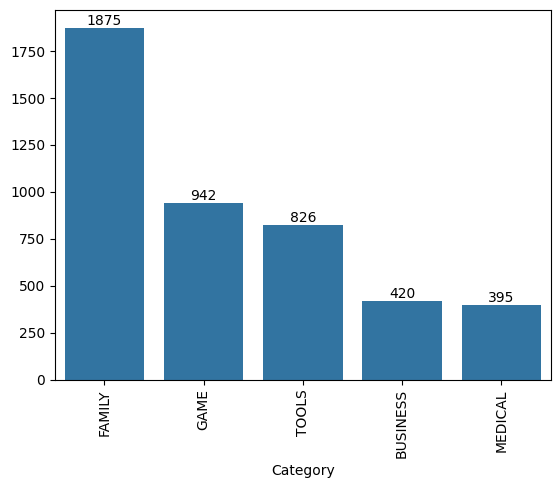

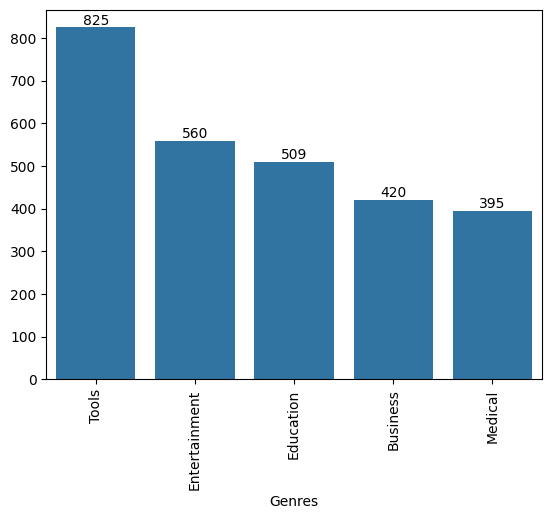

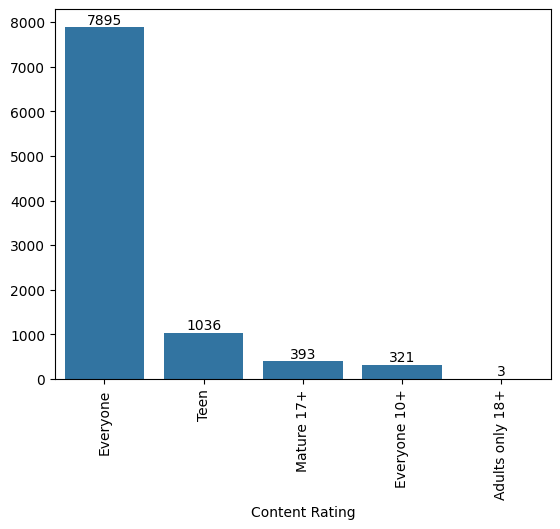

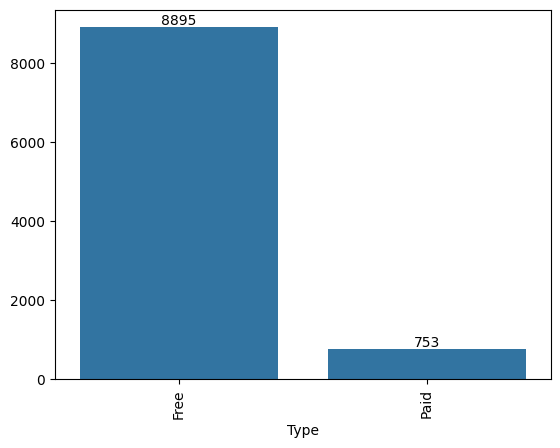

In [ ]:
target = ['Category', 'Genres', 'Content Rating', 'Type']
for value in target:
    data_category = df.groupby(value).size().sort_values(ascending=False).head()
    plt.xticks(rotation=90)
    bar = sns.barplot(data_category)
    bar.bar_label(bar.containers[0])
    plt.show()

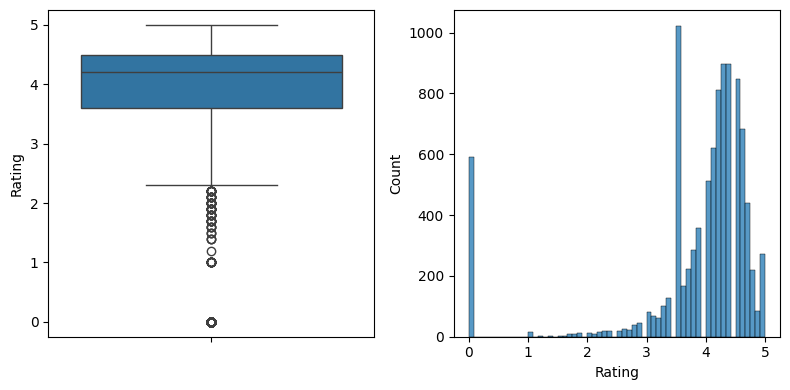

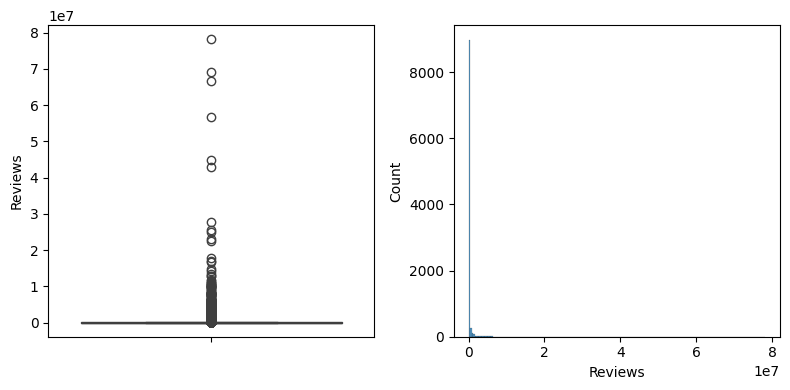

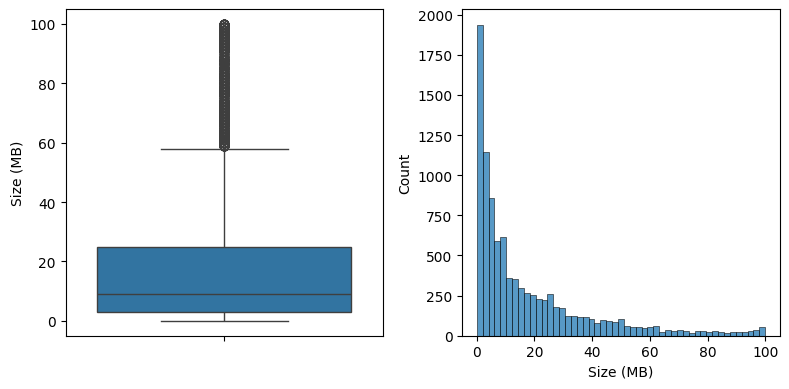

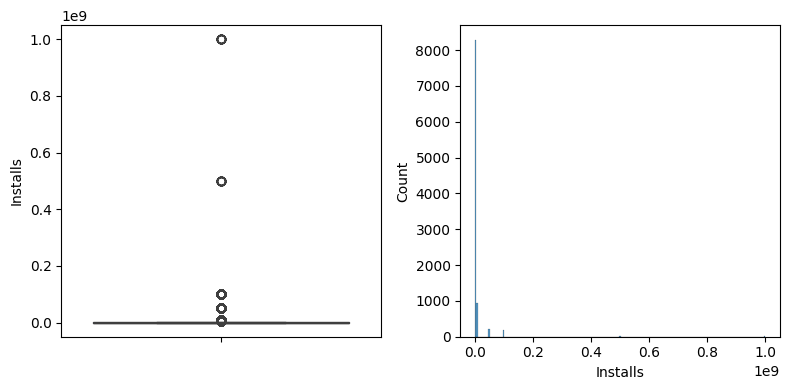

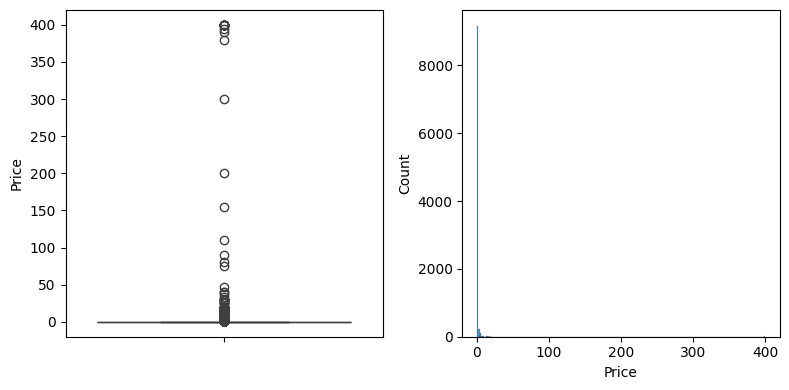

In [ ]:
target = ["Rating",	"Reviews", "Size (MB)",	"Installs",	"Price"]
for value in target:
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    sns.boxplot(df[value], ax=ax[0])
    sns.histplot(df[value], ax=ax[1])
    plt.tight_layout()
    plt.show()

In [ ]:
category = df['Category'].unique()
df_category = {}
for item in category:
    df_category[f'df_category_{item}'] = df[df['Category'] == item]


In [ ]:
df_top = {}
for key in df_category:
    top_rating = df_category[key].sort_values(by='Rating', ascending=False).head(5)
    top_rating.reset_index(drop=True, inplace=True)
    top_rating = top_rating['App']

    top_review = df_category[key].sort_values(by='Reviews', ascending=False).head(5)
    top_review.reset_index(drop=True, inplace=True)
    top_review = top_review['App']

    top_install = df_category[key].sort_values(by='Installs', ascending=False).head(5)
    top_install.reset_index(drop=True, inplace=True)
    top_install = top_install['App']

    data = pd.DataFrame({
        "Top Rating" : top_rating,
        "Top Review" : top_review,
        "Top Install" : top_install
    })

    df_top[key] = data
    print(f'Top 5 App {key}')
    display(df_top[key])

Top 5 App df_category_SPORTS


,Top Rating,Top Review,Top Install
0,EC SPORTS,FIFA Soccer,3D Bowling
1,FA Player Essentials,Top Eleven 2018 - Be a Soccer Manager,FIFA Soccer
2,FK Dedinje BGD,EA SPORTS UFC®,Cricbuzz - Live Cricket Scores & News
3,CricQuick,PES 2018 PRO EVOLUTION SOCCER,NFL
4,FK Željezničar,NBA LIVE Mobile Basketball,NBA LIVE Mobile Basketball


Top 5 App df_category_TOOLS


,Top Rating,Top Review,Top Install
0,CE Smart,Clean Master- Space Cleaner & Antivirus,Google
1,CL REPL,"Security Master - Antivirus, VPN, AppLock, Boo...",Google Translate
2,Jabbla BT,"360 Security - Free Antivirus, Booster, Cleaner",SHAREit - Transfer & Share
3,ReactNative BG Geolocation,DU Battery Saver - Battery Charger & Battery Life,Gboard - the Google Keyboard
4,CL Keyboard - Myanmar Keyboard (No Ads),Cache Cleaner-DU Speed Booster (booster & clea...,"Security Master - Antivirus, VPN, AppLock, Boo..."


Top 5 App df_category_SHOPPING


...

,Top Rating,Top Review,Top Install
0,Food-Aw - Order Food Online in Aruba,Domino's Pizza USA,Delivery yogi.
1,Bar-B-Q Rib House,Tastely,Cookpad - FREE recipe search makes fun cooking...
2,Bar-B-Q Recipes,Zomato - Restaurant Finder and Food Delivery App,Starbucks
3,SarashpazPapion (Cooking with Chef Bowls),Foursquare City Guide,Uber Eats: Local Food Delivery
4,Simple Recipes,Starbucks,Zomato - Restaurant Finder and Food Delivery App


Top 5 App df_category_LIBRARIES_AND_DEMO


,Top Rating,Top Review,Top Install
0,Eternal life,MX Player Codec (ARMv7),Aviary Stickers: Free Pack
1,Nur təfsiri 1-ci cild,Cardboard,Cardboard
2,Blackpink as if it's your last,Aviary Stickers: Free Pack,MX Player Codec (ARMv7)
3,Call Recorder,Aviary Effects: Classic,Wifi Connect Library
4,Girls Nancy Ajram Without Net,Cool Popular Ringtones 2018 🔥,Aviary Effects: Classic


Top 5 App df_category_HOUSE_AND_HOME


,Top Rating,Top Review,Top Install
0,"Viva Decora - Decoration, Photos, Architecture...",Zillow: Find Houses for Sale & Apartments for ...,tinyCam Monitor FREE
1,DIY On A Budget,Houzz Interior Design Ideas,Trulia Real Estate & Rentals
2,Redfin Real Estate,Trulia Real Estate & Rentals,Houzz Interior Design Ideas
3,Living Smart Home,Realtor.com Real Estate: Homes for Sale and Rent,Zillow: Find Houses for Sale & Apartments for ...
4,House app: beautiful everyday ~,Alfred Home Security Camera,Realtor.com Real Estate: Homes for Sale and Rent


#### Data Understanding (df_review)

In [ ]:
df_review

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
...,...,...,...,...,...
64290,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64291,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64292,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64293,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN


In [ ]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
df_review.isna().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [ ]:
df_review.duplicated().sum()

np.int64(33616)

#### Data Cleaning (df_review)

In [ ]:
df_review.dropna(inplace=True)
df_review

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000
5,10 Best Foods for You,Best way,Positive,1.000000,0.300000
...,...,...,...,...,...
64222,Housing-Real Estate & Property,Most ads older many agents ..not much owner po...,Positive,0.173333,0.486667
64223,Housing-Real Estate & Property,"If photos posted portal load, fit purpose. I'm...",Positive,0.225000,0.447222
64226,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.287500,0.250000
64227,Housing-Real Estate & Property,I property business got link SMS happy perform...,Positive,0.800000,1.000000


#### EDA (df_review)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/pikachen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/pikachen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
df_review['Translated_Review'] = df_review['Translated_Review'].astype(str).str.lower()
stop_words = set(stopwords.words('english'))

def tokenize_and_filter(text):
    tokens = word_tokenize(text)
    return [word for word in tokens if word.isalnum() and word not in stop_words]

df_review['Tokens'] = df_review['Translated_Review'].apply(tokenize_and_filter)
df_review

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Tokens
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive,1.000000,0.533333,"[like, eat, delicious, food, cooking, food, ca..."
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive,0.250000,0.288462,"[help, eating, healthy, exercise, regular, basis]"
3,10 Best Foods for You,works great especially going grocery store,Positive,0.400000,0.875000,"[works, great, especially, going, grocery, store]"
4,10 Best Foods for You,best idea us,Positive,1.000000,0.300000,"[best, idea, us]"
5,10 Best Foods for You,best way,Positive,1.000000,0.300000,"[best, way]"
...,...,...,...,...,...,...
64222,Housing-Real Estate & Property,most ads older many agents ..not much owner po...,Positive,0.173333,0.486667,"[ads, older, many, agents, much, owner, posted..."
64223,Housing-Real Estate & Property,"if photos posted portal load, fit purpose. i'm...",Positive,0.225000,0.447222,"[photos, posted, portal, load, fit, purpose, s..."
64226,Housing-Real Estate & Property,"dumb app, i wanted post property rent give opt...",Negative,-0.287500,0.250000,"[dumb, app, wanted, post, property, rent, give..."
64227,Housing-Real Estate & Property,i property business got link sms happy perform...,Positive,0.800000,1.000000,"[property, business, got, link, sms, happy, pe..."


In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /home/pikachen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/pikachen/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize(token):
    return [lemmatizer.lemmatize(word) for word in token]

df_review['Lemmatization'] = df_review['Tokens'].apply(lemmatize)

In [ ]:
df_review

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Tokens,Lemmatization
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive,1.000000,0.533333,"[like, eat, delicious, food, cooking, food, ca...","[like, eat, delicious, food, cooking, food, ca..."
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive,0.250000,0.288462,"[help, eating, healthy, exercise, regular, basis]","[help, eating, healthy, exercise, regular, basis]"
3,10 Best Foods for You,works great especially going grocery store,Positive,0.400000,0.875000,"[works, great, especially, going, grocery, store]","[work, great, especially, going, grocery, store]"
4,10 Best Foods for You,best idea us,Positive,1.000000,0.300000,"[best, idea, us]","[best, idea, u]"
5,10 Best Foods for You,best way,Positive,1.000000,0.300000,"[best, way]","[best, way]"
...,...,...,...,...,...,...,...
64222,Housing-Real Estate & Property,most ads older many agents ..not much owner po...,Positive,0.173333,0.486667,"[ads, older, many, agents, much, owner, posted...","[ad, older, many, agent, much, owner, posted, ..."
64223,Housing-Real Estate & Property,"if photos posted portal load, fit purpose. i'm...",Positive,0.225000,0.447222,"[photos, posted, portal, load, fit, purpose, s...","[photo, posted, portal, load, fit, purpose, su..."
64226,Housing-Real Estate & Property,"dumb app, i wanted post property rent give opt...",Negative,-0.287500,0.250000,"[dumb, app, wanted, post, property, rent, give...","[dumb, app, wanted, post, property, rent, give..."
64227,Housing-Real Estate & Property,i property business got link sms happy perform...,Positive,0.800000,1.000000,"[property, business, got, link, sms, happy, pe...","[property, business, got, link, sm, happy, per..."


In [ ]:
df_review['Clean Text'] = df_review['Lemmatization'].apply(lambda x: ' '.join(x))
df_review.reset_index(drop=True, inplace=True)
df_review.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Tokens,Lemmatization,Clean Text
0,10 Best Foods for You,i like eat delicious food. that's i'm cooking ...,Positive,1.00,0.533333,"[like, eat, delicious, food, cooking, food, ca...","[like, eat, delicious, food, cooking, food, ca...",like eat delicious food cooking food case 10 b...
1,10 Best Foods for You,this help eating healthy exercise regular basis,Positive,0.25,0.288462,"[help, eating, healthy, exercise, regular, basis]","[help, eating, healthy, exercise, regular, basis]",help eating healthy exercise regular basis
2,10 Best Foods for You,works great especially going grocery store,Positive,0.40,0.875000,"[works, great, especially, going, grocery, store]","[work, great, especially, going, grocery, store]",work great especially going grocery store
3,10 Best Foods for You,best idea us,Positive,1.00,0.300000,"[best, idea, us]","[best, idea, u]",best idea u
4,10 Best Foods for You,best way,Positive,1.00,0.300000,"[best, way]","[best, way]",best way


[Text(0, 0, '10299'),
 Text(0, 0, '5608'),
 Text(0, 0, '5577'),
 Text(0, 0, '5268'),
 Text(0, 0, '5152'),
 Text(0, 0, '4909'),
 Text(0, 0, '4809'),
 Text(0, 0, '4768'),
 Text(0, 0, '3455'),
 Text(0, 0, '3440')]

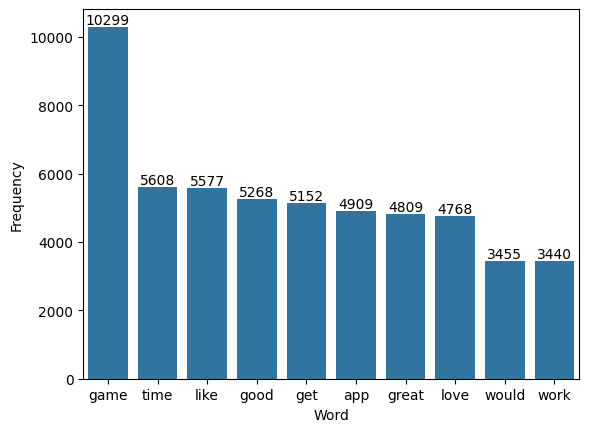

In [ ]:
from collections import Counter
df_review_tokens = df_review['Lemmatization'].explode().value_counts().reset_index()
df_review_tokens.columns = ['Word', 'Frequency']
top_10 = df_review_tokens.head(10)
bar = sns.barplot(x=top_10['Word'], y=top_10['Frequency'])
bar.bar_label(bar.containers[0])

In [ ]:
df_review.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37427.000000,37427.000000
mean,0.182171,0.492770
std,0.351318,0.259904
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


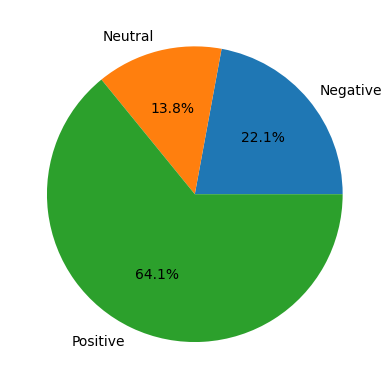

[Text(0, 0, '23998'), Text(0, 0, '8271'), Text(0, 0, '5158')]

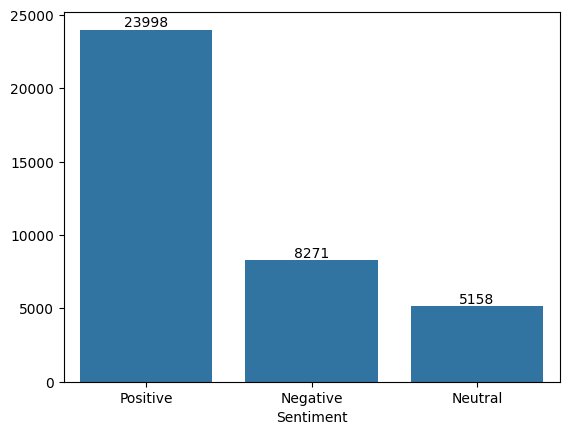

In [ ]:
df_review.groupby('Sentiment').size().plot(kind='pie', autopct='%1.1f%%')
plt.show()
bar = sns.barplot(df_review.groupby('Sentiment').size().sort_values(ascending=False))
bar.bar_label(bar.containers[0])

#### Feature Engineering

In [ ]:
df['Reviews'].corr(df['Rating'])

np.float64(0.05774365603337678)

In [ ]:
def weight_rating(data):
    xbar_data = data['Rating'].mean()
    min_data = data['Reviews'].quantile(0.9)

    def calculate(data, xbar=xbar_data, min=min_data):
        vote = data['Reviews']
        rating = data['Rating']

        return (vote / (vote + min) * rating) + (min / (vote + min) * xbar)

    data['Weight Rating'] = data.apply(calculate, axis=1)
    return data

df = weight_rating(df)
df

,App,Category,Rating,Reviews,Size (MB),Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Category_Encoded,Weight Rating
0,GollerCepte Live Score,SPORTS,4.2,9992,31.000,1000000,Free,0.00,Everyone,Sports,"May 23, 2018",6.5,4.1 and up,28,3.871763
1,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999,0.091,100000,Free,0.00,Everyone,Tools,"December 17, 2013",3.2,2.2 and up,29,3.854550
2,SnipSnap Coupon App,SHOPPING,4.2,9975,18.000,1000000,Free,0.00,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up,26,3.871739
3,US Open Tennis Championships 2018,SPORTS,4.0,9971,33.000,1000000,Free,0.00,Everyone,Sports,"June 5, 2018",7.1,5.0 and up,28,3.863163
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.000,500000,Free,0.00,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up,30,3.893158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,CE-STRONG,FAMILY,0.0,0,16.000,100,Free,0.00,Everyone,Education,"June 17, 2016",1.0.4,4.0 and up,11,3.857038
9656,Anime Mod for BM,BOOKS_AND_REFERENCE,0.0,0,8.000,100,Free,0.00,Everyone,Books & Reference,"July 28, 2017",1.0,4.0 and up,3,3.857038
9657,CE-SETRAM l’Appli,LIBRARIES_AND_DEMO,0.0,0,2.600,100,Free,0.00,Everyone,Libraries & Demo,"December 5, 2017",1.1.8,4.0.3 and up,17,3.857038
9658,Glanceable Ap Watch Face,PERSONALIZATION,0.0,0,11.000,5,Paid,0.99,Everyone,Personalization,"August 14, 2016",1.0.103,4.4 and up,23,3.857038


In [ ]:
df.drop(['Size (MB)', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Category_Encoded', 'Type', 'Price'], axis=1, inplace=True)

In [ ]:
df_review_new = df_review.copy()
df_review_new.drop(['Translated_Review', 'Tokens', 'Lemmatization', 'Clean Text'], axis=1, inplace=True)

#### Merge Dataset

In [ ]:
df = pd.merge(df, df_review_new, how='inner', on='App')
df.head()

,App,Category,Rating,Reviews,Installs,Weight Rating,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.2000,0.2000
1,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.8500,0.8750
2,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Negative,-0.1375,0.4125
3,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.0000,0.0000
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.0000,0.5000


#### Modelling

In [ ]:
df['log_Installs'] = np.log1p(df['Installs'])
df['n_Installs'] = ((df['log_Installs'] - df['log_Installs'].min()) / (df['log_Installs'].max() - df['log_Installs'].min()))
df

,App,Category,Rating,Reviews,Installs,Weight Rating,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,log_Installs,n_Installs
0,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.200000,0.200000,13.122365,0.449789
1,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.850000,0.875000,13.122365,0.449789
2,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Negative,-0.137500,0.412500,13.122365,0.449789
3,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.000000,0.000000,13.122365,0.449789
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.000000,0.500000,13.122365,0.449789
...,...,...,...,...,...,...,...,...,...,...,...
35924,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Neutral,0.000000,0.575000,18.420681,0.833321
35925,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.100000,0.383333,18.420681,0.833321
35926,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.038333,0.510000,18.420681,0.833321
35927,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.116667,0.383333,18.420681,0.833321


In [ ]:
def potential(data, install=0.3, wrating=0.3, sp=0.4):
    nilai = ((data['Weight Rating'] * wrating) + 
                               (data['n_Installs'] * install) + 
                               (data['Sentiment_Polarity'] * sp))
    return nilai

df['Potential_Score'] = df.apply(potential, axis=1)

In [ ]:
df

,App,Category,Rating,Reviews,Installs,Weight Rating,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,log_Installs,n_Installs,Potential_Score
0,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.200000,0.200000,13.122365,0.449789,1.382884
1,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Positive,0.850000,0.875000,13.122365,0.449789,1.642884
2,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Negative,-0.137500,0.412500,13.122365,0.449789,1.247884
3,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.000000,0.000000,13.122365,0.449789,1.302884
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,500000,3.893158,Neutral,0.000000,0.500000,13.122365,0.449789,1.302884
...,...,...,...,...,...,...,...,...,...,...,...,...
35924,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Neutral,0.000000,0.575000,18.420681,0.833321,1.595816
35925,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.100000,0.383333,18.420681,0.833321,1.635816
35926,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.038333,0.510000,18.420681,0.833321,1.611149
35927,Hay Day,FAMILY,4.5,10053186,100000000,4.486064,Positive,0.116667,0.383333,18.420681,0.833321,1.642482


In [ ]:
top_app = df.groupby('App').agg({'Potential_Score': 'mean',
                                 'Weight Rating' : 'first',
                                 'Installs': 'first', 
                                 'Rating': 'first', 
                                 'Sentiment_Polarity': 'mean'})
top_app = top_app.sort_values(by='Potential_Score', ascending=False).head(10)
top_app

,Potential_Score,Weight Rating,Installs,Rating,Sentiment_Polarity
App,,,,,
Google Slides,1.834289,4.036532,100000000,4.2,0.933333
Brightest Flashlight Free ®,1.805832,4.579531,50000000,4.7,0.492571
Bible,1.784247,4.629507,100000000,4.7,0.363495
"APUS Launcher - Theme, Wallpaper, Hide Apps",1.771833,4.476157,100000000,4.5,0.447473
Google Duo - High Quality Video Calls,1.757695,4.528238,500000000,4.6,0.285690
Backgrounds HD (Wallpapers),1.752547,4.536668,100000000,4.6,0.353876
"DU Recorder – Screen Recorder, Video Editor, Live",1.742207,4.725296,50000000,4.8,0.224187
Daily Workouts - Exercise Fitness Routine Trainer,1.738346,4.061177,10000000,4.4,0.800000
"CM Launcher 3D - Theme, Wallpapers, Efficient",1.735820,4.576106,100000000,4.6,0.282479


#### Conclusion